In [5]:
import numpy as np
import pandas as pd
from pandas import DataFrame
import seaborn as sns
import matplotlib.pyplot as pyplot
from sklearn import svm,datasets
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

POINT 1

In [ ]:
# Load the Iris dataset from sklearn
iris = datasets.load_iris()

# Create a DataFrame from the dataset features (4 flower measurements)
iris_frame = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add a numeric target column (class labels: 0, 1, 2)
iris_frame['target'] = iris['target']

# Map numeric targets to class names (setosa, versicolor, virginica)
iris_frame['name'] = iris_frame['target'].map(lambda x: iris['target_names'][x])

# Calculate correlation between the first 4 features (sepal length (cm)	sepal width (cm)	petal length (cm)	petal width (cm))
iris_frame.iloc[:, :4].corr()

# Group by flower species and calculate correlations separately for each class
iris_frame.iloc[:, [0,1,2,3,5]].groupby('name').corr()


sepal length (cm)  sepal width (cm)  \
name                                                                
setosa     sepal length (cm)           1.000000          0.742547   
           sepal width (cm)            0.742547          1.000000   
           petal length (cm)           0.267176          0.177700   
           petal width (cm)            0.278098          0.232752   
versicolor sepal length (cm)           1.000000          0.525911   
           sepal width (cm)            0.525911          1.000000   
           petal length (cm)           0.754049          0.560522   
           petal width (cm)            0.546461          0.663999   
virginica  sepal length (cm)           1.000000          0.457228   
           sepal width (cm)            0.457228          1.000000   
           petal length (cm)           0.864225          0.401045   
           petal width (cm)            0.281108          0.537728   

                              petal length (cm)  petal width (cm)  
name                                                               
setosa     sepal length (cm)           0.267176          0.278098  
           sepal width (cm)            0.177700          0.232752  
           petal length (cm)           1.000000          0.331630  
           petal width (cm)            0.331630          1.000000  
versicolor sepal length (cm)           0.754049          0.546461  
           sepal width (cm)            0.560522          0.663999  
           petal length (cm)           1.000000          0.786668  
           petal width (cm)            0.786668          1.000000  
virginica  sepal length (cm)           0.864225          0.281108  
           sepal width (cm)            0.401045          0.537728  
           petal length (cm)           1.000000          0.322108  
           petal width (cm)            0.322108          1.000000

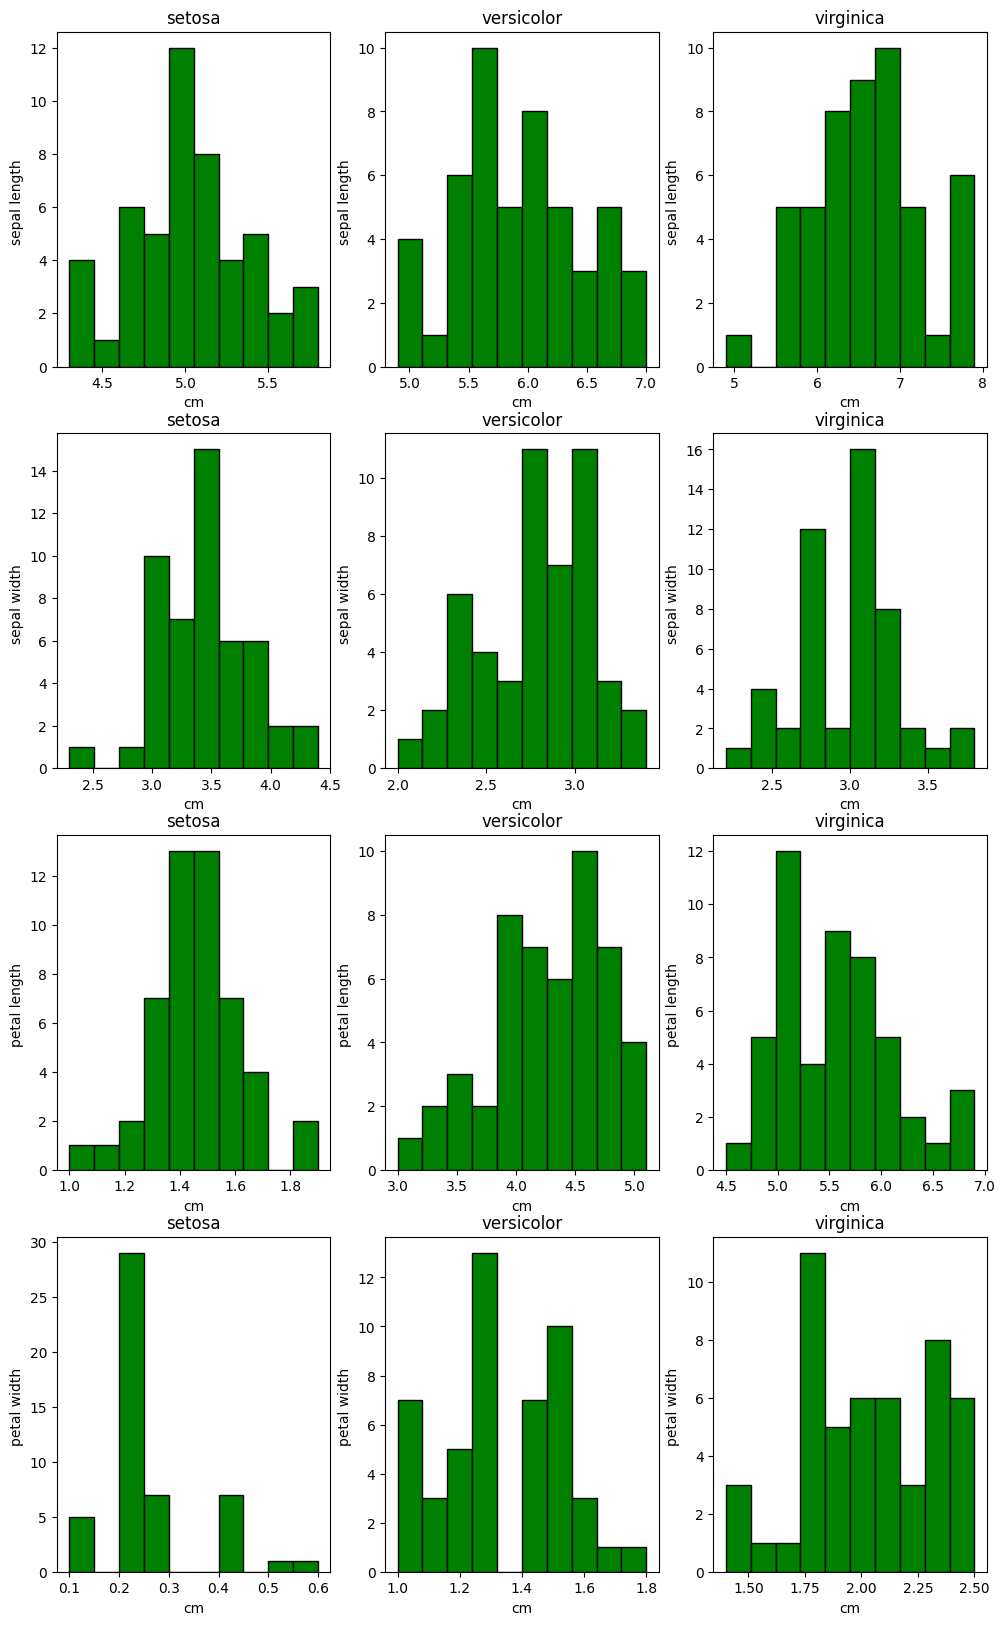

In [14]:
# Create a figure with a specific size (width=12, height=20)
pyplot.figure(figsize=(12, 20))

plot_number = 0  # Counter to keep track of subplot positions

# Loop through each feature (sepal length, sepal width, petal length, petal width)
for feature_name in iris['feature_names']:
    # Loop through each class (setosa, versicolor, virginica)
    for target_name in iris['target_names']:
        plot_number += 1  # Increase subplot index
        
        # Create a subplot in a 4x3 grid (4 features × 3 classes = 12 plots)
        pyplot.subplot(4, 3, plot_number)
        
        # Plot a histogram of the current feature values for the given class
        pyplot.hist(iris_frame.loc[iris_frame['name'] == target_name, feature_name], color='green',edgecolor="black" )
        
        # Set plot title and axis labels
        pyplot.title(target_name)
        pyplot.xlabel('cm')
        # Remove the unit ' (cm)' from the feature name for a cleaner y-label
        pyplot.ylabel(feature_name[:-4])


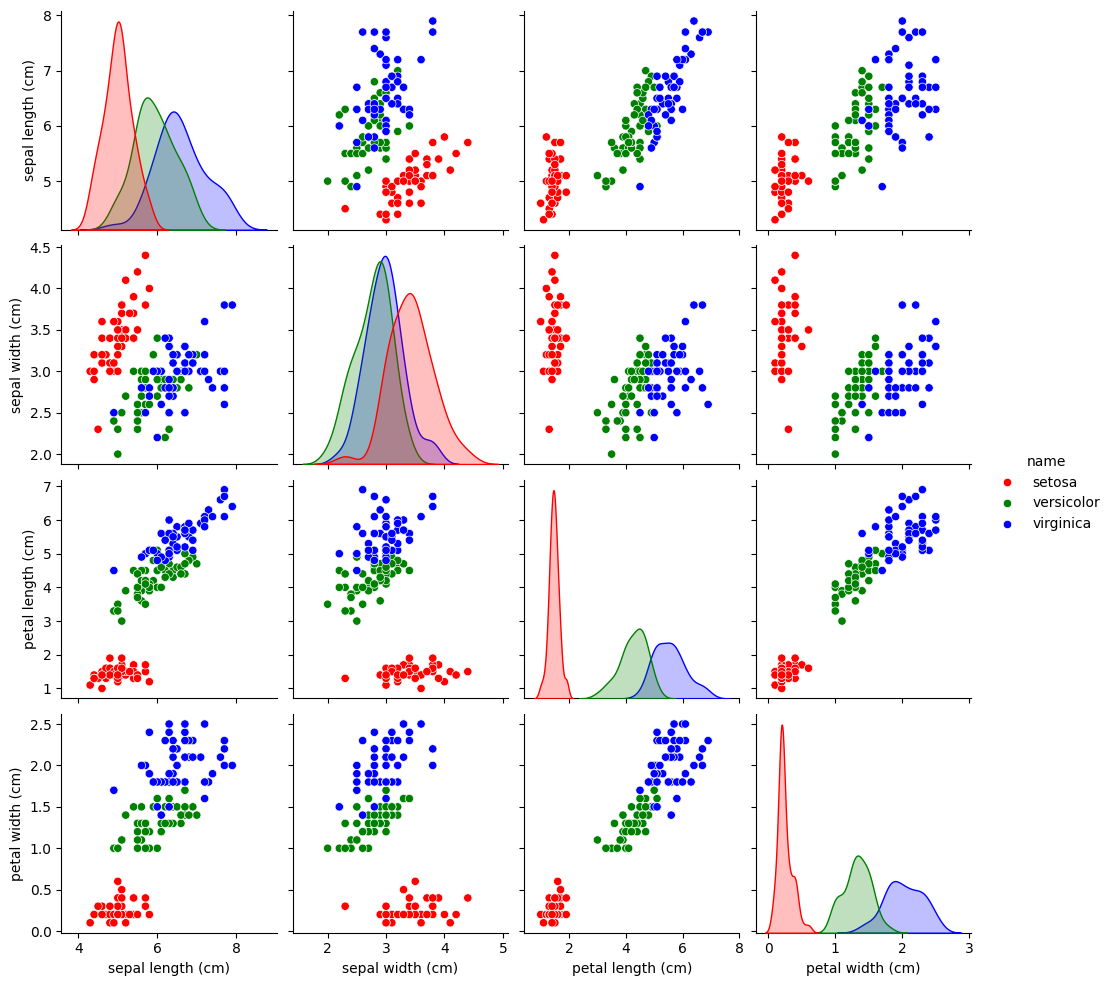

In [ ]:
## Create a scatterplot matrix for the selected features and class labels
# It shows pairwise relationships between features, with points colored by species

custom_palette = {
    "setosa": "red",
    "versicolor": "green",
    "virginica": "blue"
}

sns.pairplot(
    iris_frame.iloc[:, [0, 1, 2, 3, 5]],
    hue="name",
    palette=custom_palette 
)

POINT 2

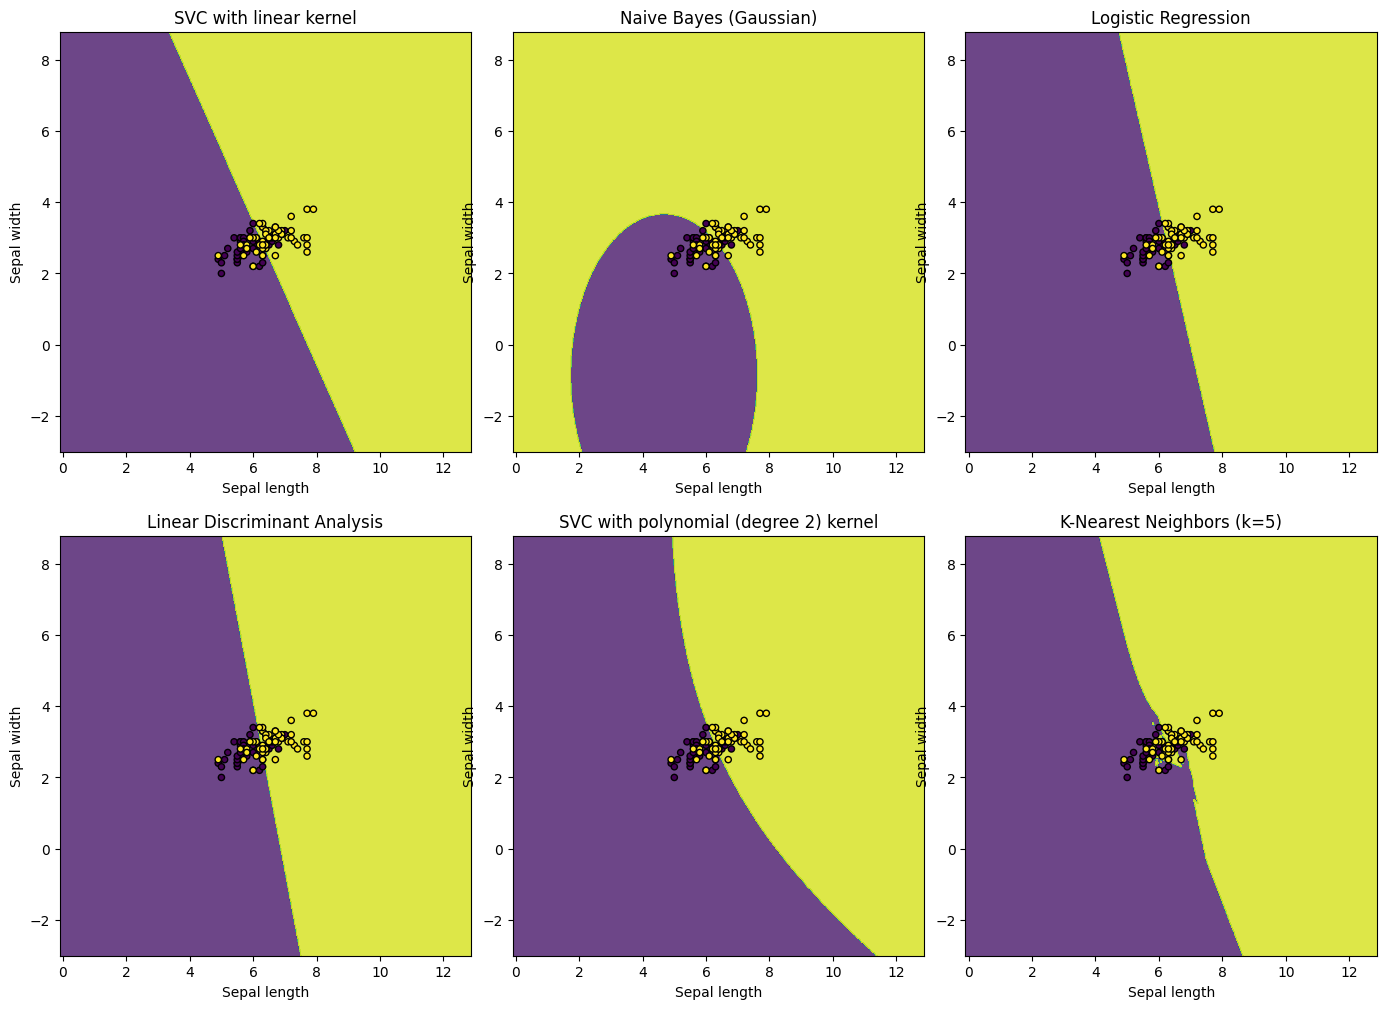

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Function to create a meshgrid over feature space for decision boundary visualization
def make_meshgrid(x, y, h=.02):
    d = 5
    x_min, x_max = x.min() - d, x.max() + d
    y_min, y_max = y.min() - d, y.max() + d
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

# Function to plot decision boundaries for a trained classifier
def plot_contours(ax, clf, xx, yy, **params):
    # Predict labels for each point on the grid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # Draw filled contour plot
    out = ax.contourf(xx, yy, Z, **params)
    return out

# Use only two features (sepal length and width), excluding class setosa
X = iris.data[iris.target!=0, :2]
y = iris.target[iris.target!=0]

# Regularization parameter for SVM
C = 1.0

# Define different classification models to compare
models = [
    svm.SVC(kernel='linear', C=C, probability=True),   # Linear SVM
    GaussianNB(),                                     # Naive Bayes
    LogisticRegression(random_state=0),               # Logistic Regression
    LinearDiscriminantAnalysis(solver="svd", store_covariance=True),  # LDA
    svm.SVC(kernel='poly', degree=2, gamma='auto', C=C, probability=True), # Polynomial SVM
    KNeighborsClassifier(n_neighbors=5)                      # KNN
]

# Train all models on the dataset
for clf in models:
    clf.fit(X, y)

# Titles for each subplot
titles = [
    'SVC with linear kernel',
    'Naive Bayes (Gaussian)',
    'Logistic Regression',
    'Linear Discriminant Analysis',
    'SVC with polynomial (degree 2) kernel',
    'K-Nearest Neighbors (k=5)'
]

# Create a 2x3 grid of subplots
fig, sub = plt.subplots(2, 3, figsize=(17,12))
plt.subplots_adjust(wspace=0.1, hspace=0.2)

# Prepare the meshgrid
X0, X1 = X[:, 0], X[:, 1]
xx, yy = make_meshgrid(X0, X1)

# For each classifier, plot the decision boundary and training points
for clf, title, ax in zip(models, titles, sub.flatten()):
    plot_contours(ax, clf, xx, yy,
                  cmap=plt.cm.viridis, alpha=0.8)
    ax.scatter(X0, X1, c=y, cmap=plt.cm.viridis, s=20, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Sepal length')
    ax.set_ylabel('Sepal width')
    ax.set_title(title)

# Show all plots
plt.show()


POINT 3

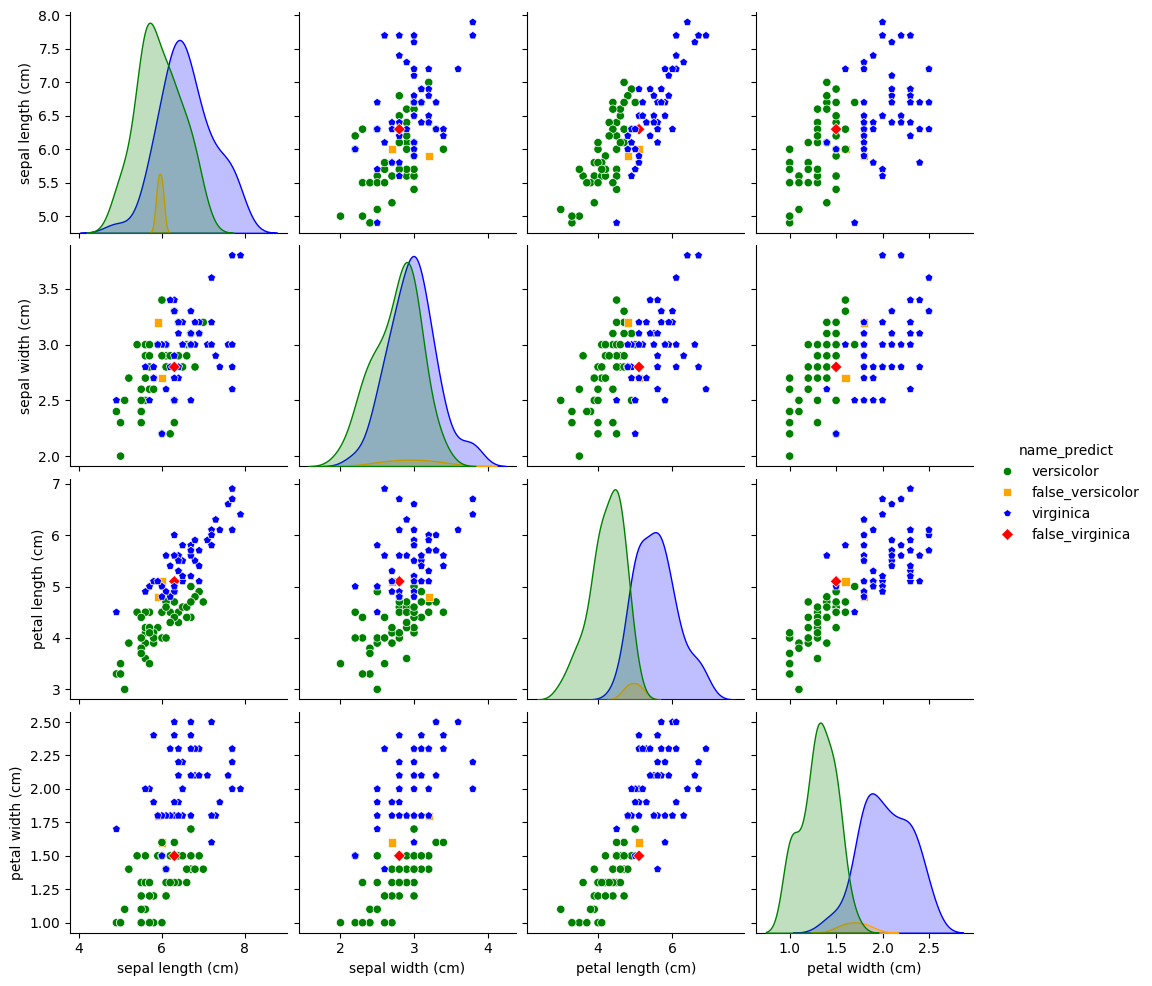

In [33]:
# Create a subset of the iris dataset excluding class setosa
iris_frame_2 = iris_frame[iris_frame.target != 0].copy()

# Features (all 4) and labels
X = iris_frame_2.iloc[:, :4].values
y = iris_frame_2['target'].values

# Train Linear Discriminant Analysis model and predict
lda = LinearDiscriminantAnalysis(solver="svd", store_covariance=True).fit(X, y)
y_pred = lda.predict(X)

# Compare predictions with true labels
iris_frame_2['target_predict'] = y - y_pred

# Assign predicted class names: correct → true label, incorrect → custom "false_*"
iris_frame_2['name_predict'] = iris_frame_2.apply(
    lambda row: row['name'] if row['target_predict'] == 0 
                else ('false_virginica' if row['target_predict'] == 1 else 'false_versicolor'),
    axis=1
)

# Custom palette for visualization
custom_palette = {
    "versicolor": "green",
    "virginica": "blue",
    "false_virginica": "red",
    "false_versicolor": "orange"
}

# Visualize pairwise feature relationships with predicted labels
sns.pairplot(
    iris_frame_2[["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)", "name_predict"]],
    hue="name_predict",
    markers=["o", "s", "p", "D"],
    palette=custom_palette
)
